# Introduction to Pandas

Pandas is a powerful Python library designed for efficient data manipulation and analysis, built on top of NumPy. It provides two primary data structures: **Series**, a one-dimensional labeled array, and **DataFrame**, a two-dimensional table-like structure with labeled rows and columns. These structures allow users to easily import, clean, transform, and analyze structured data from various sources such as CSV, Excel, SQL databases, and JSON files. Pandas offers intuitive functions for **indexing, selecting, and filtering** data, making it easy to perform operations like slicing, conditional filtering, and aggregation.  

Beyond basic data handling, Pandas excels at **data transformation** with functions for handling missing values, merging datasets, reshaping tables (pivoting and melting), and performing group-wise computations using `.groupby()`. It also supports **time-series analysis**, allowing users to work with date/time data efficiently. Additionally, Pandas integrates seamlessly with Matplotlib and Seaborn, enabling quick and effective **data visualization**. Its ability to handle large datasets, combined with vectorized operations, makes it a go-to tool for data analysis, machine learning preprocessing, and business intelligence applications.

This Jupyter Notebook will guide you through the basics of Pandas, a powerful Python library for data manipulation and analysis.
By the end of this notebook, you will be able to:

- Create and manipulate Pandas Series and DataFrames
- Load and inspect datasets
- Perform data cleaning and transformation
- Aggregate and group data
- Merge and join datasets
- Visualize data with Pandas

Estimated study time: 4 hours

In [1]:
# Install Pandas if not already installed
!pip install pandas matplotlib seaborn

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Pandas Series

A Series in Pandas is a one-dimensional labeled array that can hold data of any type, such as integers, floats, strings, or Python objects. It is similar to a column in a spreadsheet or a dictionary where each value has an associated index. The index provides labels for data points, allowing for quick and efficient data retrieval.

First, we'll create a Series.

In [2]:
# Creating a Series
data = [10, 20, 30, 40, 50]
series = pd.Series(data, index=['A', 'B', 'C', 'D', 'E'])
print("Series Example:")
print(series)

Series Example:
A    10
B    20
C    30
D    40
E    50
dtype: int64


## Pandas DataFrames

A pandas DataFrame is basically a table, kind of like a spreadsheet or SQL table, but in Python. It holds data in rows and columns, where each column can be a different data type (numbers, strings, etc.). You can think of it as a collection of series (one-dimensional arrays) stacked together.

Here are a few core concepts that make up a pandas DataFrame:

1. **Rows and Columns**: DataFrames have both rows (like records) and columns (like features or attributes). Rows are indexed with numbers or custom labels, while columns usually have labels that you can name.

2. **Index**: This is like the label for each row. By default, it’s just a range of numbers (0, 1, 2, etc.), but you can set it to anything that uniquely identifies each row.

3. **Columns**: Each column in a DataFrame is a pandas Series. A Series is like a list, but with an index attached, making it easier to access or manipulate the data.

4. **Data Types**: Each column can hold different types of data, like integers, floats, strings, or booleans. It’s flexible enough to handle multiple types in the same structure.

5. **Operations**: You can perform various operations on DataFrames like filtering rows, selecting specific columns, applying functions, merging with other DataFrames, and much more. It’s like a toolbox for handling structured data.

To sum it up, a pandas DataFrame is a powerful and flexible structure for working with tabular data in Python. You can manipulate it, clean it, and perform analysis with just a few lines of code.

Next, we'll create a DataFrame.

In [3]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [25, 30, 35, 40, 45],
    'Score': [85, 90, 78, 92, 88]
}
df = pd.DataFrame(data)
print("\nDataFrame Example:")
print(df)


DataFrame Example:
      Name  Age  Score
0    Alice   25     85
1      Bob   30     90
2  Charlie   35     78
3    David   40     92
4      Eva   45     88


## Loading and Inspecting Data

In the next code we'll use an example data set from Seaborne. Seaborn is a Python data visualization library based on Matplotlib that provides a high-level interface for creating attractive and informative statistical graphics. Here, we will only use the example dataset from Seaborne.

In [4]:
# Load a sample dataset from seaborn
iris = sns.load_dataset('iris')
print("\nFirst 5 Rows:")
print(iris.head())
print("\nSummary Statistics:")
print(iris.describe())
print("\nData Types:")
print(iris.dtypes)


First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Summary Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Data Types:
sepal_length    float64
sep

## Data Cleaning and Transformation

In pandas, data cleaning and transformations are essential steps for preparing raw data for analysis. Data cleaning involves identifying and correcting errors, inconsistencies, or missing values in the dataset. This may include tasks like filling in or dropping missing values, correcting data types, removing duplicates, or dealing with outliers. Cleaning ensures the data is accurate, complete, and in a usable format for analysis.

Data transformations, on the other hand, focus on modifying the data to better suit the needs of the analysis. This could include tasks like normalizing or scaling numerical values, encoding categorical variables, aggregating data, or creating new derived columns. Transformations allow analysts to manipulate the data so it aligns with the goals of the analysis, ensuring it is in the right structure and format for modeling, visualization, or reporting. Together, data cleaning and transformations are crucial for turning raw, messy data into meaningful insights.

Pandas has powerful tools for data cleaning and transformation.

First, check if there are any missing values.

In [16]:
# Check for missing values
print(iris.isna().sum())

SepalLength     0
SepalWidth      0
petal_length    0
petal_width     0
species         0
dtype: int64


There are no missing data in the iris set. In this case, the `dropna()` will have no effect.

In [6]:
# Handling Missing Values
iris.dropna(inplace=True)  # Drop missing values
#iris.fillna(iris.mean(), inplace=True)  # Alternatively, fill missing values with column mean

# Renaming Columns
iris.rename(columns={'sepal_length': 'SepalLength', 'sepal_width': 'SepalWidth'}, inplace=True)

# Filtering Data
filtered_df = iris[iris['species'] == 'setosa']
print("\nFiltered Data:")
print(filtered_df.head())


Filtered Data:
   SepalLength  SepalWidth  petal_length  petal_width species
0          5.1         3.5           1.4          0.2  setosa
1          4.9         3.0           1.4          0.2  setosa
2          4.7         3.2           1.3          0.2  setosa
3          4.6         3.1           1.5          0.2  setosa
4          5.0         3.6           1.4          0.2  setosa


## Aggregation and Grouping

In pandas, aggregation and grouping are powerful techniques used to summarize and analyze data. **Grouping** involves splitting the data into subsets based on certain criteria (e.g., a column value) and then performing operations on each subset. Once the data is grouped, **aggregation** functions like `sum()`, `mean()`, `count()`, or `min()` can be applied to summarize or extract insights from each group. This process allows for efficient analysis of large datasets by organizing them into meaningful groups and applying operations to understand patterns or trends.

These operations are similar to those used in relational databases, where you can use `GROUP BY` to divide data into groups based on a column and then apply aggregation functions like `SUM()`, `AVG()`, or `COUNT()`. In both pandas and databases, grouping and aggregation help to reduce complexity by transforming raw data into concise summaries. The key difference is that pandas operates entirely in memory and provides more flexibility for complex data manipulation, while databases are optimized for handling large datasets stored on disk and managing large-scale queries.

In [7]:
# Grouping Data by Species
grouped = iris.groupby('species').mean()
print("\nGrouped Mean Values:")
print(grouped)


Grouped Mean Values:
            SepalLength  SepalWidth  petal_length  petal_width
species                                                       
setosa            5.006       3.428         1.462        0.246
versicolor        5.936       2.770         4.260        1.326
virginica         6.588       2.974         5.552        2.026


In [13]:
iris['SepalLength'].isnull().sum()

np.int64(0)

## Merging and Joining DataFrames

In pandas, **merging** and **joining** are techniques used to combine multiple DataFrames based on common columns or indices. **Merging** involves combining two DataFrames using a specific column or index as a key, much like performing a SQL `JOIN` operation. You can control the type of merge (e.g., inner, outer, left, right) to define how rows from the two DataFrames are aligned and combined. **Joining** is a similar operation, but it is typically done using the index of one DataFrame and the index or a column in the other. Both methods are helpful for integrating related data from different sources or tables into a unified dataset for analysis.

These operations are conceptually similar to **JOIN** operations in relational databases. In databases, you can join tables on common keys (such as primary and foreign keys) to combine related data. Like SQL joins, pandas merges and joins allow you to combine data from different sources based on matching values, providing flexibility in how data is aligned and combined. However, pandas operates entirely in memory, which can make it faster for smaller datasets, while databases are optimized for handling large datasets stored on disk with sophisticated indexing and query optimization.

For demonstrating a join, we will first create a second table containing the flower count for the separate species.

In [8]:
# Creating another dataset
data2 = {
    'species': ['setosa', 'versicolor', 'virginica'],
    'flower_count': [50, 60, 70]
}
df2 = pd.DataFrame(data2)

The way to join these two tables / dataframes is to use a join. In pandas this is called `merge()`. Check the pandas manual for what kind of join is used in this case. From databases you may remember there are 4 types of attribute joins:

In a database management system (DBMS), there are several types of joins used to combine rows from two or more tables based on a related column. Here are the main types of joins:

    Inner Join:
        Explanation: An inner join returns only the rows where there is a match in both tables. If a row in one table does not have a corresponding match in the other table, it is excluded from the result.
        Use Case: When you want to retrieve only the records that have matching values in both tables.

    Left Join:
        Explanation: A left join returns all rows from the left table (the table specified first), and the matched rows from the right table. If there is no match, the result will contain NULL values for the columns from the right table.
        Use Case: When you want to retain all records from the left table, even if there's no corresponding match in the right table.

    Right Join:
        Explanation: A right join is similar to a left join but returns all rows from the right table (the second table), along with the matched rows from the left table. If there is no match, the result will contain NULL values for the left table's columns.
        Use Case: When you want to retain all records from the right table, even if there's no corresponding match in the left table.

    Outer Join (Full Join):
        Explanation: A full join returns all rows when there is a match in either the left or right table. If a row has no match in one table, NULL values are returned for the columns of the table without a match.
        Use Case: When you want to include all records from both tables, even if there are no matches between them.

In addition to these joins, a Cartesian product of two tables is sometimes refered to as a cross join:

    Cross Join:
        Explanation: A cross join returns the Cartesian product of two tables, meaning it will return every combination of rows from the left table with every row from the right table. This can result in a very large number of rows, especially with large tables.
        Use Case: When you need every possible combination of rows from both tables, such as when generating all possible pairings or combinations.

Which join is used below and why?

In [9]:
# Merging DataFrames
merged_df = pd.merge(iris, df2, on='species', how='left')
print("\nMerged DataFrame:")
print(merged_df.head())


Merged DataFrame:
   SepalLength  SepalWidth  petal_length  petal_width species  flower_count
0          5.1         3.5           1.4          0.2  setosa            50
1          4.9         3.0           1.4          0.2  setosa            50
2          4.7         3.2           1.3          0.2  setosa            50
3          4.6         3.1           1.5          0.2  setosa            50
4          5.0         3.6           1.4          0.2  setosa            50


## Data Visualization

In pandas, **data visualization** is used to create visual representations of data to help identify patterns, trends, and outliers, and to communicate findings in a more intuitive and accessible way. By integrating with libraries like **Matplotlib**, **Seaborn**, and **Plotly**, pandas allows users to generate a wide variety of charts and graphs, such as line plots, bar charts, histograms, scatter plots, and heatmaps. Visualizing data makes it easier to understand complex relationships and distributions, and it aids in drawing conclusions from the data that might not be immediately obvious through raw numbers alone.

Data visualization in pandas is particularly useful during exploratory data analysis (EDA) to uncover insights before diving into more advanced analysis or modeling. It helps to summarize large datasets, compare different variables, and detect anomalies. Just like in traditional business intelligence tools or databases, visualizing data is an essential part of making data-driven decisions and presenting results to others in a clear, impactful way.

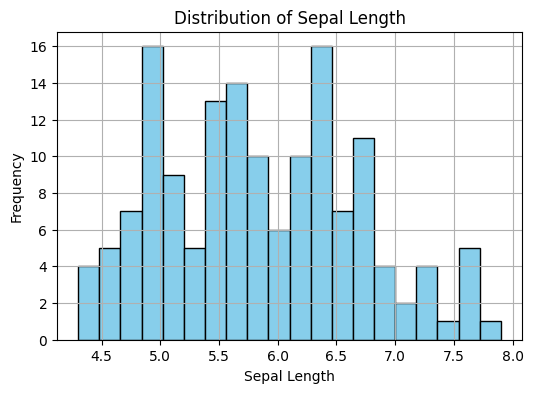

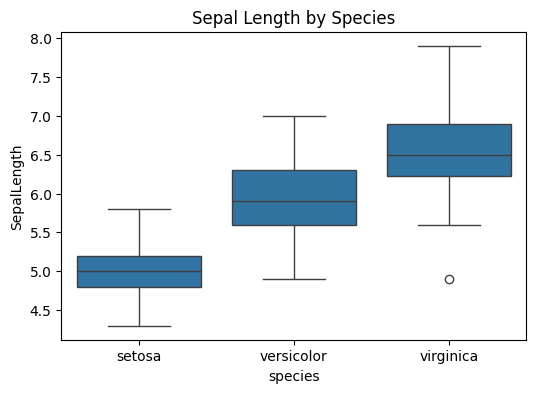

In [10]:
# Histogram of Sepal Length
plt.figure(figsize=(6,4))
iris['SepalLength'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='species', y='SepalLength', data=iris)
plt.title("Sepal Length by Species")
plt.show()

## Exercises

Try the following exercises to reinforce your learning:

1. Load a CSV file into a Pandas DataFrame (e.g., a dataset from Kaggle or a public repository).
2. Check for missing values and handle them appropriately.
3. Add a new calculated column to a DataFrame.
4. Group data by a categorical column and calculate aggregated statistics.
5. Merge two datasets with common columns.
6. Create a visualization using Pandas or Seaborn.

In [ ]:
set

TypeError: 'int' object is not iterable